In [ ]:
# ===============================
# SVM with Hyperparameter Tuning
# Upload Dataset + Train Model
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

from IPython.display import display
from ipywidgets import FileUpload

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# 1 Upload Dataset
# -----------------------------
print("Please upload your CSV dataset")

upload = FileUpload(accept='.csv', multiple=False)
display(upload)

# Wait until user uploads
while len(upload.value) == 0:
    pass

# Read uploaded file
file_name = list(upload.value.keys())[0]
content = upload.value[file_name]['content']

df = pd.read_csv(io.BytesIO(content))

print("\nDataset Loaded Successfully")
print("Dataset Shape:", df.shape)
print("\nColumns in Dataset:")
print(df.columns)

# -----------------------------
# 2 Ask for Target Column
# -----------------------------
target_column = input("\nEnter the target column name: ")

X = df.drop(target_column, axis=1)
y = df[target_column]

# -----------------------------
# 3 Feature Scaling
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# 4 Train Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# -----------------------------
# 5 Hyperparameter Grid
# -----------------------------
param_grid = {
    'C':[0.1,1,10,100],
    'gamma':[1,0.1,0.01,0.001],
    'kernel':['rbf']
}

# -----------------------------
# 6 GridSearchCV
# -----------------------------
print("\nStarting Grid Search...")

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    verbose=1
)

grid.fit(X_train, y_train)

print("\nBest Parameters Found:", grid.best_params_)

# -----------------------------
# 7 Prediction
# -----------------------------
y_pred = grid.predict(X_test)

# -----------------------------
# 8 Performance
# -----------------------------
acc = accuracy_score(y_test, y_pred)

print("\nFinal Model Performance")
print("Accuracy:", acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# -----------------------------
# 9 Confusion Matrix
# -----------------------------
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(f"Confusion Matrix (Accuracy: {acc:.2%})")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()


Saving diabetes.csv to diabetes.csv

Dataset Loaded Successfully
Dataset Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Running Grid Search...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Parameters: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}

Accuracy: 0.7727272727272727

Classification Report:

             

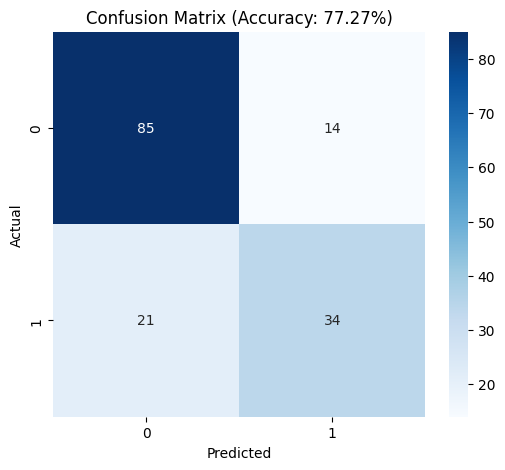

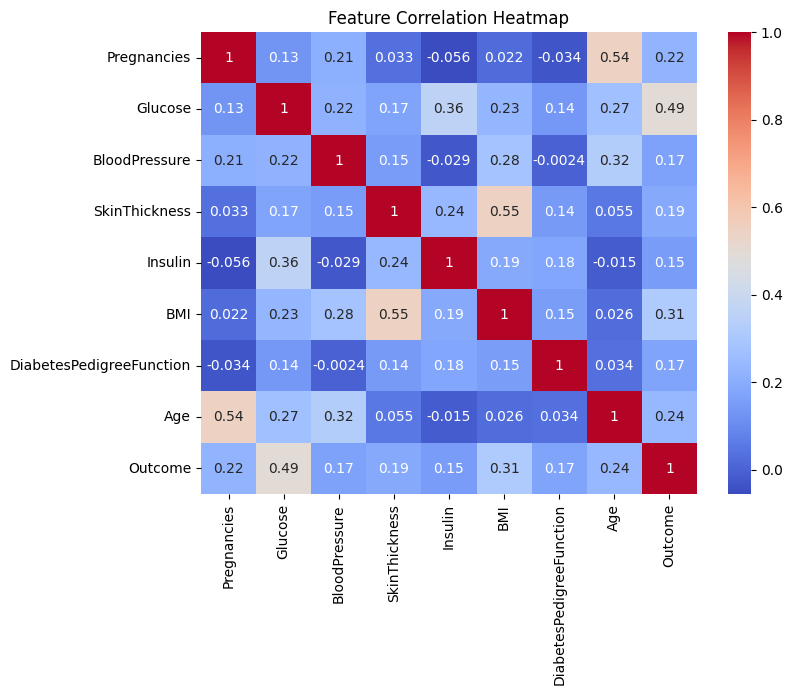

In [3]:
# ===============================
# SVM on Diabetes Dataset
# Upload Dataset + Train Model
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Upload dataset
from google.colab import files
uploaded = files.upload()

# Read dataset
df = pd.read_csv("diabetes.csv")

print("\nDataset Loaded Successfully")
print("Dataset Shape:", df.shape)
print(df.head())

# Replace invalid zeros with median
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in cols:
    df[col] = df[col].replace(0, df[col].median())

# Features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Hyperparameter grid
param_grid = {
    'C':[0.1,1,10,100],
    'gamma':[1,0.1,0.01,0.001],
    'kernel':['rbf']
}

# GridSearchCV
print("\nRunning Grid Search...")
grid = GridSearchCV(SVC(), param_grid, cv=5, verbose=1)
grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)

# Prediction
y_pred = grid.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)

print("\nAccuracy:", acc)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix (Accuracy: {acc:.2%})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()
